In [3]:
import os

path = r"C:\Users\moham\.cache\kagglehub\datasets\miguelroca\global-health-nutrition-mortality-economic-data\versions\1"

csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]

print("CSV files found:", csv_files)

csv_file = os.path.join(path, csv_files[0])
print("Full path to CSV:", csv_file)

CSV files found: ['UnifiedDataset.csv']
Full path to CSV: C:\Users\moham\.cache\kagglehub\datasets\miguelroca\global-health-nutrition-mortality-economic-data\versions\1\UnifiedDataset.csv


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor

# 1️⃣ Reading the Data
- Using `pandas` to read CSV.
- Display first 5 rows, dataset info, and basic statistics.


In [5]:
df = pd.read_csv(csv_file, encoding='ascii', delimiter=',')

print("Shape of dataset:", df.shape)

print("\n First 5 rows:")
display(df.head())

print("\n Dataset info:")
print(df.info())

print("\n Summary statistics:")
display(df.describe())

Shape of dataset: (22050, 150)

 First 5 rows:


,Country,Year,Gender,Life Expectancy,Infant Mortality Rate,Low CI Value Infant Mortality Rate,High CI Value Infant Mortality Rate,Under 5 Mortality Rate,Low CI Value Under 5 Mortality Rate,High CI Value Under 5 Mortality Rate,...,Cereal Consumption Rye,Cereal Consumption Barley,Cereal Consumption Sorghum,Cereal Consumption Maize,Cereal Consumption Wheat,Cereal Consumption Rice,Diet Calories Animal Protein,Diet Calories Plant Protein,Diet Calories Fat,Diet Calories Carbohydrates
0,Afghanistan,1990,Both sexes,50.331,120.4,111.2,130.9,177.7,162.5,194.3,...,NaN,103.0,NaN,201.0,1195.0,174.0,67.80,197.08,435.60,1613.52
1,Afghanistan,1990,Female,51.442,114.2,105.1,124.7,173.1,158.0,189.7,...,NaN,103.0,NaN,201.0,1195.0,174.0,67.80,197.08,435.60,1613.52
2,Afghanistan,1990,Male,49.281,126.2,116.4,137.5,182.0,166.6,199.3,...,NaN,103.0,NaN,201.0,1195.0,174.0,67.80,197.08,435.60,1613.52
3,Afghanistan,1991,Both sexes,50.999,116.8,108.2,126.2,171.7,157.6,186.9,...,NaN,94.0,NaN,164.0,1043.0,159.0,64.96,173.68,370.08,1435.28
4,Afghanistan,1991,Female,52.119,110.7,102.1,120.4,167.1,153.0,182.6,...,NaN,94.0,NaN,164.0,1043.0,159.0,64.96,173.68,370.08,1435.28



 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22050 entries, 0 to 22049
Columns: 150 entries, Country to Diet Calories Carbohydrates
dtypes: float64(147), int64(1), object(2)
memory usage: 25.2+ MB
None

 Summary statistics:


,Year,Life Expectancy,Infant Mortality Rate,Low CI Value Infant Mortality Rate,High CI Value Infant Mortality Rate,Under 5 Mortality Rate,Low CI Value Under 5 Mortality Rate,High CI Value Under 5 Mortality Rate,% Death Cardiovascular,Low CI Value % Death Cardiovascular,...,Cereal Consumption Rye,Cereal Consumption Barley,Cereal Consumption Sorghum,Cereal Consumption Maize,Cereal Consumption Wheat,Cereal Consumption Rice,Diet Calories Animal Protein,Diet Calories Plant Protein,Diet Calories Fat,Diet Calories Carbohydrates
count,22050.000000,22050.000000,14457.000000,14457.000000,14457.000000,14457.000000,14457.000000,14457.000000,10800.000000,10800.000000,...,10161.000000,12144.000000,5342.000000,12822.000000,12966.000000,12966.000000,12078.000000,12078.000000,12078.000000,12078.000000
mean,2004.500000,69.011830,33.729899,30.097944,38.143873,48.502710,42.752957,55.672736,22.169139,16.147065,...,17.201063,12.313159,73.021528,181.448214,537.452183,290.820453,134.528544,169.131598,714.624106,1684.262200
std,8.655638,9.691938,32.347492,29.505812,36.258293,53.518014,48.317563,60.642327,9.051913,6.703007,...,50.105988,33.976204,105.262163,253.944113,370.905713,342.077524,81.250777,37.500723,318.400275,231.852571
min,1990.000000,24.834000,1.420000,0.780000,1.780000,1.680000,0.850000,2.220000,4.400000,3.200000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.760000,82.800000,137.790000,892.180000
25%,1997.000000,63.082000,8.400000,7.780000,9.040000,9.860000,9.150000,10.600000,15.600000,11.600000,...,0.000000,0.000000,5.000000,21.000000,234.000000,48.000000,62.280000,143.760000,456.840000,1532.980000
50%,2004.500000,71.134000,21.410000,18.450000,24.440000,25.280000,21.820000,29.160000,21.300000,14.800000,...,0.000000,2.000000,24.000000,78.000000,501.000000,129.000000,119.400000,163.840000,657.135000,1684.750000
75%,2012.000000,76.254000,50.390000,43.890000,57.690000,70.700000,59.820000,82.810000,27.200000,19.300000,...,5.000000,9.000000,101.000000,230.000000,771.000000,437.750000,201.480000,189.960000,923.040000,1825.040000
max,2019.000000,87.747000,189.200000,173.300000,207.600000,331.100000,309.400000,354.400000,64.100000,50.800000,...,598.000000,486.000000,588.000000,1435.000000,1769.000000,1754.000000,405.160000,330.760000,1542.240000,2564.870000


In [6]:
df["Gender"].value_counts()
df.groupby("Gender")["Life Expectancy"].mean()

Gender
Both sexes    69.752115
Female        71.117888
Male          66.174515
Name: Life Expectancy, dtype: float64

# 2️⃣ Handling Categorical Data
- Columns: `Country` and `Gender`.
- Use `OneHotEncoder` to convert them to numeric columns.


In [7]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['Country','Gender']

encoder = OneHotEncoder(handle_unknown='ignore')

encoded_data = encoder.fit_transform(df[categorical_cols])

encoded_df = pd.DataFrame(encoded_data.toarray(), columns=encoder.get_feature_names_out(categorical_cols))

df_encoded = pd.concat([df.drop(categorical_cols, axis=1), encoded_df], axis=1)

df_encoded.head()

,Year,Life Expectancy,Infant Mortality Rate,Low CI Value Infant Mortality Rate,High CI Value Infant Mortality Rate,Under 5 Mortality Rate,Low CI Value Under 5 Mortality Rate,High CI Value Under 5 Mortality Rate,% Death Cardiovascular,Low CI Value % Death Cardiovascular,...,Country_Western Africa,Country_Western Asia,Country_Western Sahara,Country_World,Country_Yemen,Country_Zambia,Country_Zimbabwe,Gender_Both sexes,Gender_Female,Gender_Male
0,1990,50.331,120.4,111.2,130.9,177.7,162.5,194.3,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1990,51.442,114.2,105.1,124.7,173.1,158.0,189.7,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1990,49.281,126.2,116.4,137.5,182.0,166.6,199.3,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1991,50.999,116.8,108.2,126.2,171.7,157.6,186.9,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1991,52.119,110.7,102.1,120.4,167.1,153.0,182.6,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# 3️⃣ Handling Missing Values
- Check missing values:


In [8]:
print(df_encoded.isnull().sum())

Year                                      0
Life Expectancy                           0
Infant Mortality Rate                  7593
Low CI Value Infant Mortality Rate     7593
High CI Value Infant Mortality Rate    7593
                                       ... 
Country_Zambia                            0
Country_Zimbabwe                          0
Gender_Both sexes                         0
Gender_Female                             0
Gender_Male                               0
Length: 432, dtype: int64


In [9]:
df_encoded = df_encoded.fillna(df_encoded.mean())


print("Number of duplicate rows:", df_encoded.duplicated().sum())

Number of duplicate rows: 0


# 5️⃣ Detecting Outliers
- Using Z-score on `Life Expectancy`:


In [10]:
from scipy import stats

z_scores = stats.zscore(df["Life Expectancy"])
z_outliers = df[np.abs(z_scores) > 3]

print("\n Outliers in Z-score:")
print(z_outliers)


 Outliers in Z-score:
            Country  Year      Gender  Life Expectancy  Infant Mortality Rate  \
16410        Rwanda  1990  Both sexes           33.413                  91.86   
16411        Rwanda  1990      Female           34.941                  85.18   
16412        Rwanda  1990        Male           31.941                  98.21   
16413        Rwanda  1991  Both sexes           29.248                  94.65   
16414        Rwanda  1991      Female           30.761                  87.96   
16415        Rwanda  1991        Male           27.800                 101.00   
16416        Rwanda  1992  Both sexes           26.691                  98.83   
16417        Rwanda  1992      Female           28.161                  92.06   
16418        Rwanda  1992        Male           25.288                 105.30   
16419        Rwanda  1993  Both sexes           26.172                 104.90   
16420        Rwanda  1993      Female           27.571                  97.90   
16421

# 6️⃣ Correlation Analysis
- Top & bottom correlated features with Life Expectancy:


C:\Users\moham\AppData\Local\Temp\ipykernel_29452\3643806383.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=selected_features.values, y=selected_features.index, palette="coolwarm")


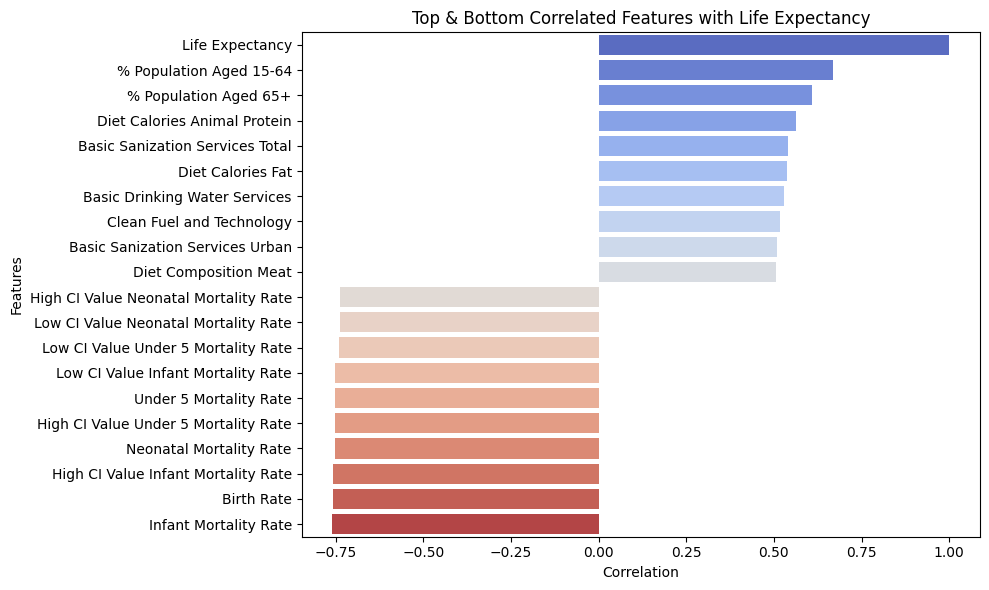

In [11]:
correlation = df_encoded.corr()["Life Expectancy"].sort_values(ascending=False)

top_features = correlation.head(10)
bottom_features = correlation.tail(10)

selected_features = pd.concat([top_features, bottom_features])

plt.figure(figsize=(10,6))
sns.barplot(x=selected_features.values, y=selected_features.index, palette="coolwarm")
plt.title("Top & Bottom Correlated Features with Life Expectancy")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# 7️⃣ Normalization 


In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
normalized_df = scaler.fit_transform(df_encoded)

normalized_df = pd.DataFrame(normalized_df, columns=df_encoded.columns)
display(normalized_df.head())

,Year,Life Expectancy,Infant Mortality Rate,Low CI Value Infant Mortality Rate,High CI Value Infant Mortality Rate,Under 5 Mortality Rate,Low CI Value Under 5 Mortality Rate,High CI Value Under 5 Mortality Rate,% Death Cardiovascular,Low CI Value % Death Cardiovascular,...,Country_Western Africa,Country_Western Asia,Country_Western Sahara,Country_World,Country_Yemen,Country_Zambia,Country_Zimbabwe,Gender_Both sexes,Gender_Female,Gender_Male
0,0.000000,0.405274,0.633614,0.640042,0.627344,0.534333,0.523902,0.545403,0.297641,0.271997,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.000000,0.422933,0.600596,0.604684,0.597221,0.520369,0.509318,0.532341,0.297641,0.271997,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.000000,0.388584,0.664501,0.670183,0.659411,0.547386,0.537190,0.559600,0.297641,0.271997,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.034483,0.415892,0.614442,0.622652,0.604509,0.516119,0.508021,0.524391,0.297641,0.271997,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.034483,0.433694,0.581958,0.587294,0.576329,0.502155,0.493113,0.512181,0.297641,0.271997,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# 9️⃣ Train-Test Split


In [13]:
y = normalized_df["Life Expectancy"]
X = normalized_df.drop("Life Expectancy", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔟 Random Forest Regressor


In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest R²:", r2_score(y_test, y_pred_rf))
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rf))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Random Forest: Actual vs Predicted")
plt.tight_layout()
plt.show()

# 1️⃣1️⃣ Bagging with Decision Trees


Bagging Decision Tree R²: 0.9943567297613419
Bagging Decision Tree MAE: 0.006914657952950396
Bagging Decision Tree MSE: 0.00013672942644812956


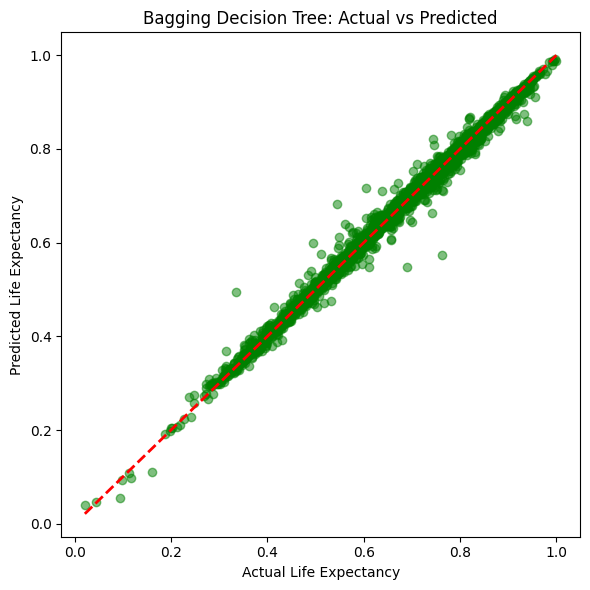

In [ ]:
dtree_reg = DecisionTreeRegressor(random_state=42)

bagging_reg = BaggingRegressor(estimator=dtree_reg, n_estimators=50, random_state=42)

bagging_reg.fit(X_train, y_train)

y_pred_bagging = bagging_reg.predict(X_test)

print("Bagging Decision Tree R²:", r2_score(y_test, y_pred_bagging))
print("Bagging Decision Tree MAE:", mean_absolute_error(y_test, y_pred_bagging))
print("Bagging Decision Tree MSE:", mean_squared_error(y_test, y_pred_bagging))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_bagging, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Bagging Decision Tree: Actual vs Predicted")
plt.tight_layout()
plt.show()

# 1️⃣2️⃣ Gradient Boosting Regressor


Gradient Boosting R²: 0.9349468487448511
Gradient Boosting MAE: 0.029224124401486792
Gradient Boosting MSE: 0.001576157030161112


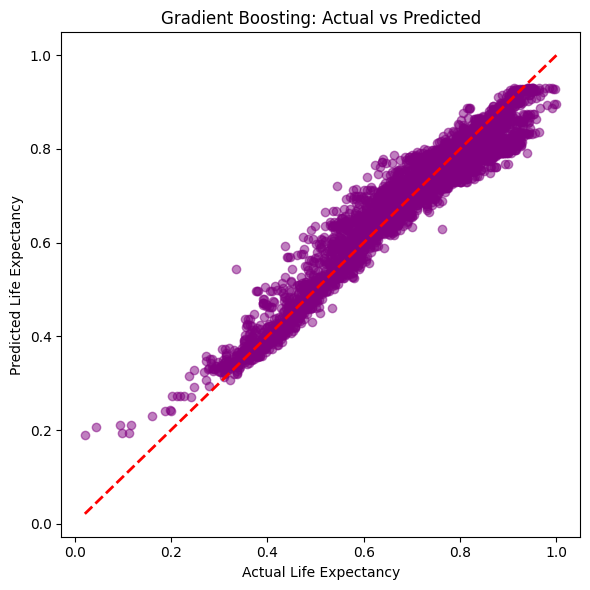

In [ ]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting R²:", r2_score(y_test, y_pred_gb))
print("Gradient Boosting MAE:", mean_absolute_error(y_test, y_pred_gb))
print("Gradient Boosting MSE:", mean_squared_error(y_test, y_pred_gb))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_gb, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Gradient Boosting: Actual vs Predicted")
plt.tight_layout()
plt.show()